# Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Combined Data.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (53043, 3)
Columns: ['Unnamed: 0', 'statement', 'status']


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [2]:
print(df['status'].value_counts())
print(df.isnull().sum())
print(df.dtypes)

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64
Unnamed: 0      0
statement     362
status          0
dtype: int64
Unnamed: 0     int64
statement     object
status        object
dtype: object


# Data cleaning

In [3]:
import re

df = df.dropna(subset=['statement', 'status'])
df = df.drop_duplicates(subset=['statement'])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['statement'].apply(clean_text)

df = df[df['clean_text'].apply(lambda x: len(x.split()) >= 5)]

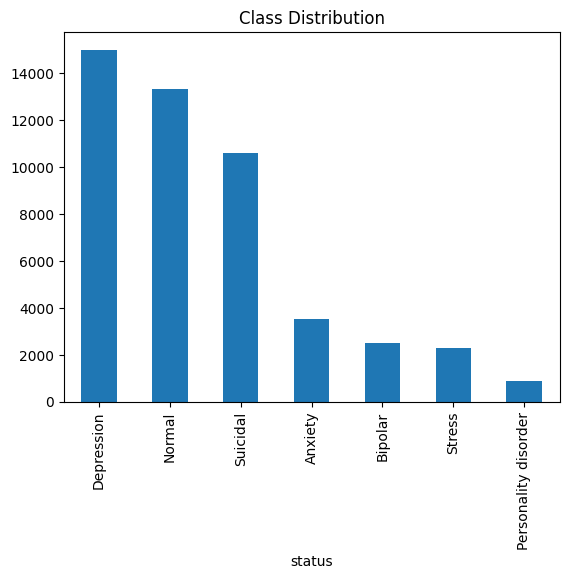

In [4]:
df['status'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.savefig('class_distribution.png')
plt.show()

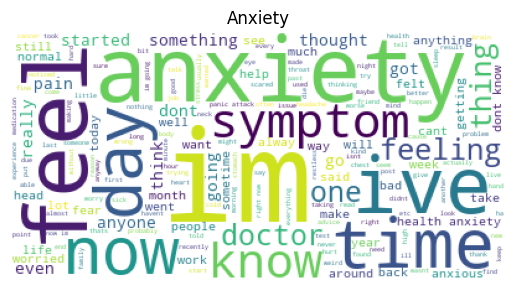

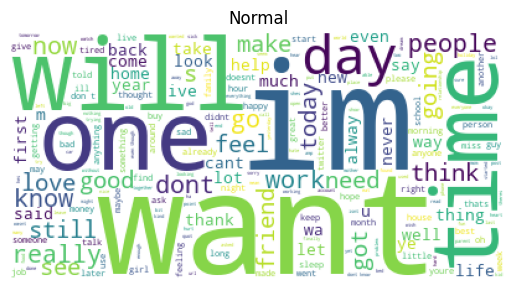

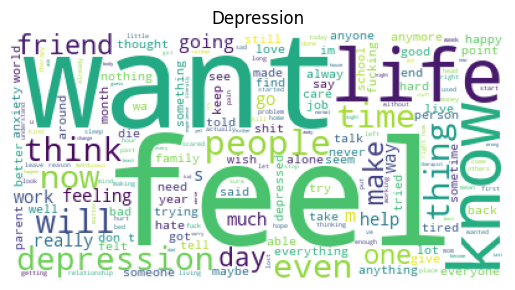

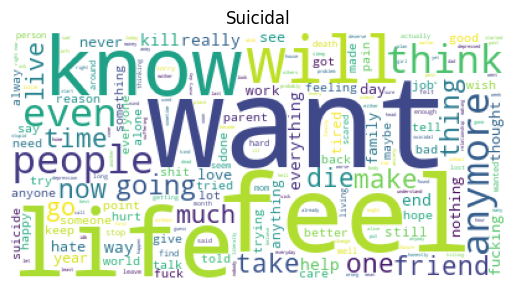

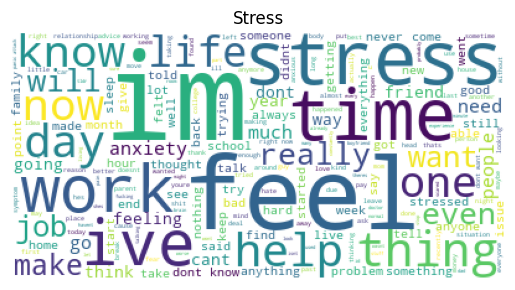

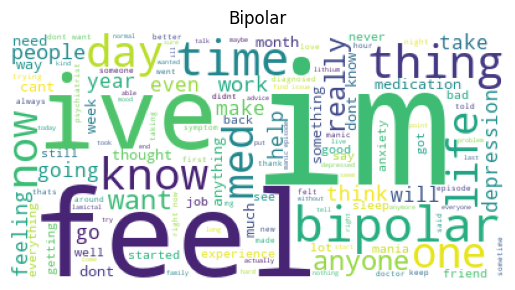

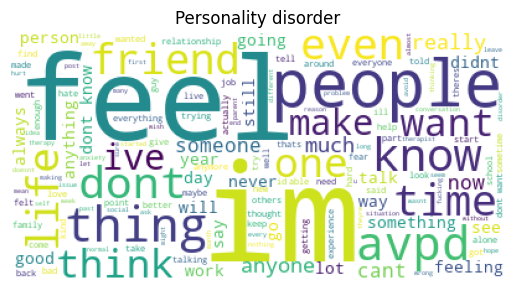

In [5]:
for category in df['status'].unique():
    text = ' '.join(df[df['status'] == category]['clean_text'])
    wc = WordCloud(background_color='white').generate(text)
    plt.imshow(wc)
    plt.title(category)
    plt.axis('off')
    plt.savefig(f'wordcloud_{category}.png')
    plt.show()

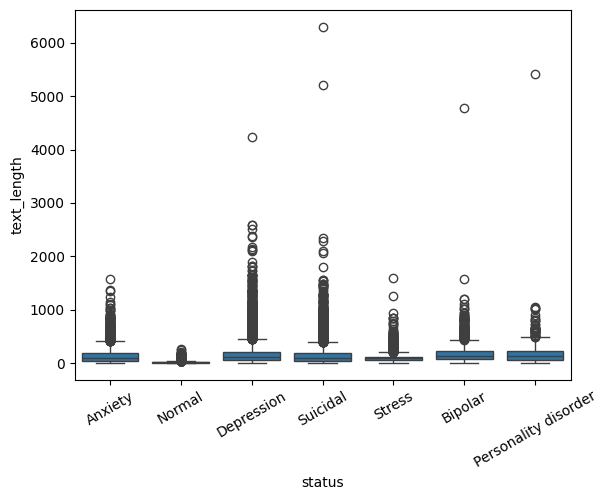

In [6]:
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

sns.boxplot(x='status', y='text_length', data=df)
plt.xticks(rotation=30)
plt.show()

In [7]:
df[['clean_text', 'status']].to_csv('mental_health_cleaned.csv', index=False)

# Feature Engineering & ML Models

In [13]:
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('mental_health_cleaned.csv')

le = LabelEncoder()
df['label'] = le.fit_transform(df['status'])

In [14]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [11]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import time

print("Training Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced',
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)

lr_preds = lr_model.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_preds)

print(f"Done in {time.time()-start:.1f}s")
print(f"\nLogistic Regression Accuracy: {lr_acc*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, lr_preds, target_names=le.classes_))

Training Logistic Regression...
Done in 22.3s

Logistic Regression Accuracy: 75.79%

Detailed Report:
                      precision    recall  f1-score   support

             Anxiety       0.77      0.81      0.79       706
             Bipolar       0.73      0.78      0.75       500
          Depression       0.81      0.63      0.71      3002
              Normal       0.87      0.92      0.90      2664
Personality disorder       0.46      0.65      0.54       179
              Stress       0.49      0.66      0.57       457
            Suicidal       0.67      0.74      0.70      2121

            accuracy                           0.76      9629
           macro avg       0.69      0.74      0.71      9629
        weighted avg       0.77      0.76      0.76      9629



In [ ]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier
import time

print("Training Random Forest (takes 2-3 mins)...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1           # use all CPU cores
)
rf_model.fit(X_train_tfidf, y_train)

rf_preds = rf_model.predict(X_test_tfidf)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Done in {time.time()-start:.1f}s")
print(f"\nRandom Forest Accuracy: {rf_acc*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, rf_preds, target_names=le.classes_))


Training Random Forest (takes 2-3 mins)...
Done in 343.7s

Random Forest Accuracy: 71.05%

Detailed Report:
                      precision    recall  f1-score   support

             Anxiety       0.79      0.65      0.72       706
             Bipolar       0.88      0.58      0.70       500
          Depression       0.62      0.77      0.69      3002
              Normal       0.78      0.95      0.86      2664
Personality disorder       1.00      0.15      0.26       179
              Stress       0.70      0.19      0.30       457
            Suicidal       0.71      0.53      0.61      2121

            accuracy                           0.71      9629
           macro avg       0.78      0.55      0.59      9629
        weighted avg       0.72      0.71      0.69      9629



In [ ]:
# SVM (usually best baseline for text)
import time
from sklearn.svm import LinearSVC

print("Training SVM...")
start = time.time()

svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
svm_model.fit(X_train_tfidf, y_train)

svm_preds = svm_model.predict(X_test_tfidf)
svm_acc = accuracy_score(y_test, svm_preds)

print(f"Done in {time.time()-start:.1f}s")
print(f"\nSVM Accuracy: {svm_acc*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, svm_preds, target_names=le.classes_))

Training SVM...
Done in 15.7s

SVM Accuracy: 75.35%

Detailed Report:
                      precision    recall  f1-score   support

             Anxiety       0.77      0.79      0.78       706
             Bipolar       0.72      0.78      0.75       500
          Depression       0.76      0.67      0.71      3002
              Normal       0.87      0.93      0.90      2664
Personality disorder       0.59      0.51      0.55       179
              Stress       0.50      0.55      0.53       457
            Suicidal       0.67      0.70      0.68      2121

            accuracy                           0.75      9629
           macro avg       0.70      0.70      0.70      9629
        weighted avg       0.75      0.75      0.75      9629



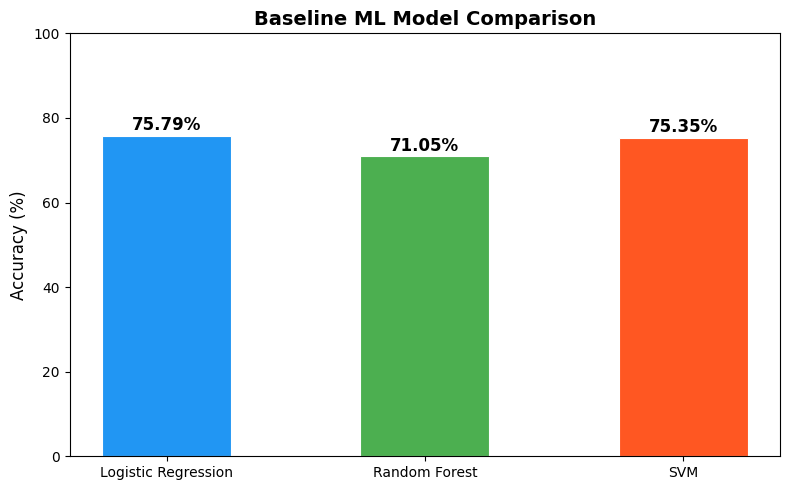


=== SUMMARY ===
Logistic Regression      : 75.79%
Random Forest            : 71.05%
SVM                      : 75.35%

Best baseline model: Logistic Regression


In [ ]:
#  Compare all 3 models

import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest', 'SVM']
accuracies = [lr_acc*100, rf_acc*100, svm_acc*100]
colors = ['#2196F3', '#4CAF50', '#FF5722']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, edgecolor='white', linewidth=0.8, width=0.5)

# Add accuracy labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc:.2f}%',
             ha='center', va='bottom',
             fontsize=12, fontweight='bold')

plt.title('Baseline ML Model Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print("\n=== SUMMARY ===")
for m, a in zip(models, accuracies):
    print(f"{m:25s}: {a:.2f}%")
print(f"\nBest baseline model: {models[accuracies.index(max(accuracies))]}")

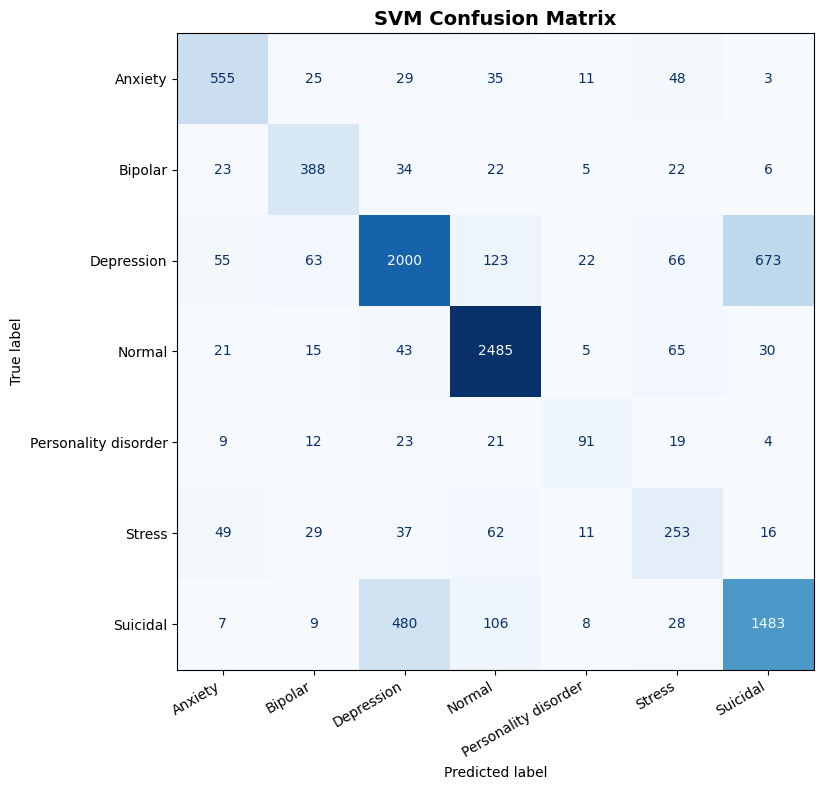

In [ ]:
# Confusion matrix (use your best model, usually SVM)

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, svm_preds)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('SVM Confusion Matrix', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(svm, 'svm_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(le, 'label_encoder.pkl')